<a href="https://colab.research.google.com/github/aswinrj401-del/AI-DEEP-VISION/blob/main/Day_4_Tumor_Prediction(ML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

zip_path = "/content/archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("data(set")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import os
import cv2
import numpy as np

dataset_path = "/content/dataset/brain_tumor_dataset"

images = []
labels = []

for label in os.listdir(dataset_path):
    label_path = os.path.join(dataset_path, label)

    if os.path.isdir(label_path):
        for file in os.listdir(label_path):
            img_path = os.path.join(label_path, file)

            img = cv2.imread(img_path)
            img = cv2.resize(img, (128, 128))

            images.append(img)
            labels.append(label)

print("Total Images:", len(images))
print("Labels:", set(labels))

Total Images: 253
Labels: {'no', 'yes'}


In [ ]:
image_arr = np.array(images) / 255.0   # Normalization
image_arr

array([[[[0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157],
         ...,
         [0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157]],

        [[0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157],
         ...,
         [0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157]],

        [[0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157],
         ...,
         [0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157]],

        ...,

        [[0.00392157, 0.00392157, 0.00392157],
         [0.00392157, 0.00392157, 0.00392157]

In [ ]:
image_np = np.array(images)

print(image_np.shape)

(253, 128, 128, 3)


In [ ]:
# Colour Conversion

import cv2
import numpy as np

gray_images = []

for img in images:
    if len(img.shape) == 3:          # Color image
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:                            # Already grayscale
        gray = img
    gray_images.append(gray)

gray_images = np.array(gray_images)

print(gray_images.shape)

(253, 128, 128)


In [ ]:
img = cv2.resize(img, (64, 64))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)

# Images
X = image_arr

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Flatten images
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,      # Number of trees
    max_depth=20,          # Maximum tree depth
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train the model
rf_model.fit(X_train_flat, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test_flat)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy: {:.2f}%".format(accuracy * 100))

Random Forest Accuracy: 76.47%


Image 1: /content/Test_img_1.jpg
Predicted Class: yes

Image 2: /content/Test_img_2.jpg
Predicted Class: no

Image 3: /content/Test_img_3.jpg
Predicted Class: yes

Image 4: /content/Test_img_4.png
Predicted Class: yes



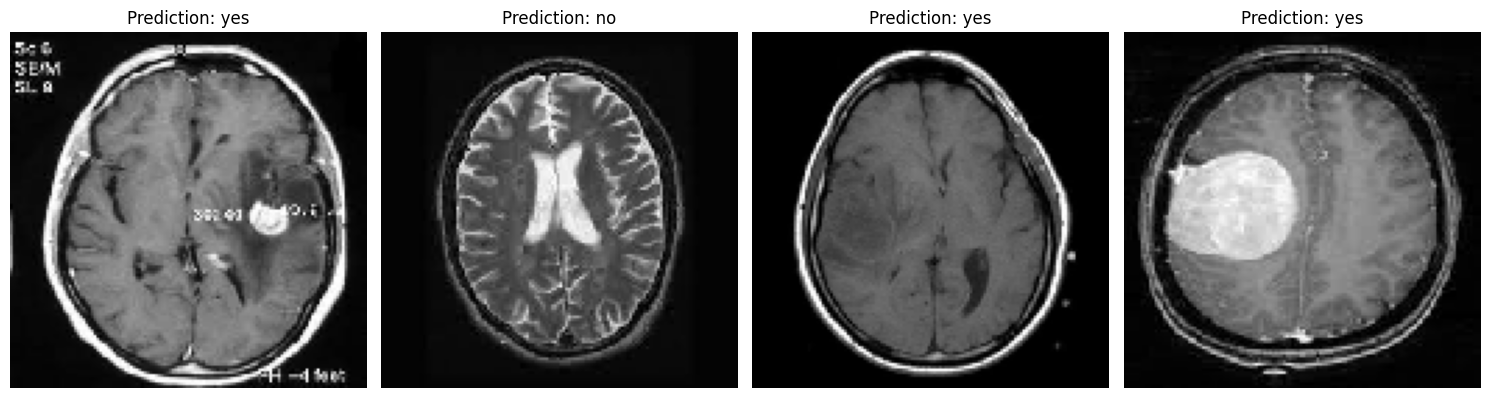

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# List of image paths
image_paths = [
    "/content/Test_img_1.jpg",
    "/content/Test_img_2.jpg",
    "/content/Test_img_3.jpg",
    "/content/Test_img_4.png"
]

plt.figure(figsize=(15, 5))

for i, img_path in enumerate(image_paths):
    # Load image
    img = image.load_img(img_path, target_size=(128, 128))

    # Display image
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.axis("off")

    # Preprocess image
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = img_array.reshape(1, -1)

    # Predict
    prediction = rf_model.predict(img_array)
    predicted_class = le.inverse_transform(prediction)

    # Set title
    plt.title(f"Prediction: {predicted_class[0]}")

    # Print prediction
    print(f"Image {i+1}: {img_path}")
    print(f"Predicted Class: {predicted_class[0]}\n")

plt.tight_layout()
plt.show()